## End-to-End Sales and Customer Analytics using SQL, Python, and Power BI

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import os
os.chdir("/Users/vanshikapandita/Downloads/archive")
os.listdir()

# Load datasets
orders = pd.read_csv("olist_orders_dataset.csv")
payments = pd.read_csv("olist_order_payments_dataset.csv")
customers = pd.read_csv("olist_customers_dataset.csv")
order_items = pd.read_csv("olist_order_items_dataset.csv")
products = pd.read_csv("olist_products_dataset.csv")

In [2]:
df = orders.merge(payments, on="order_id") \
           .merge(customers, on="customer_id") \
           .merge(order_items, on="order_id") \
           .merge(products, on="product_id")

In [3]:
# Convert to datetime
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])

df['day_of_week'] = df['order_purchase_timestamp'].dt.day_name()

# Extract useful features
df['month'] = df['order_purchase_timestamp'].dt.to_period('M')
df['day_of_week'] = df['order_purchase_timestamp'].dt.day_name()

In [4]:
df.to_csv("final_dataset.csv", index=False)
df.sample(5000).to_csv("final_dataset_sample.csv", index=False)

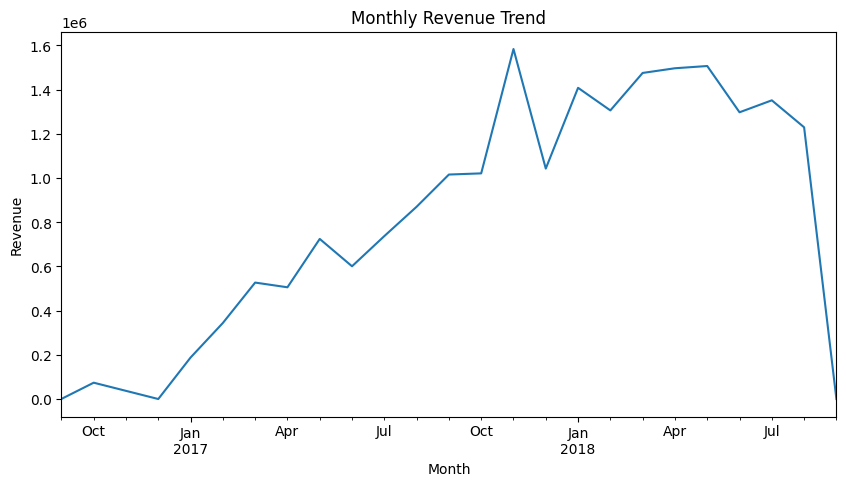

In [5]:
monthly_revenue = df.groupby('month')['payment_value'].sum()

monthly_revenue.plot(figsize=(10,5))
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.show()

## Insight 1 — Revenue Trend
Revenue shows a strong upward trend from early 2017, peaking around late 2017 (~1.6M), followed by relatively stable high revenue in 2018. The sharp drop at the end is likely due to incomplete data for the final month.

In [6]:
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])
df['day_of_week'] = df['order_purchase_timestamp'].dt.day_name()

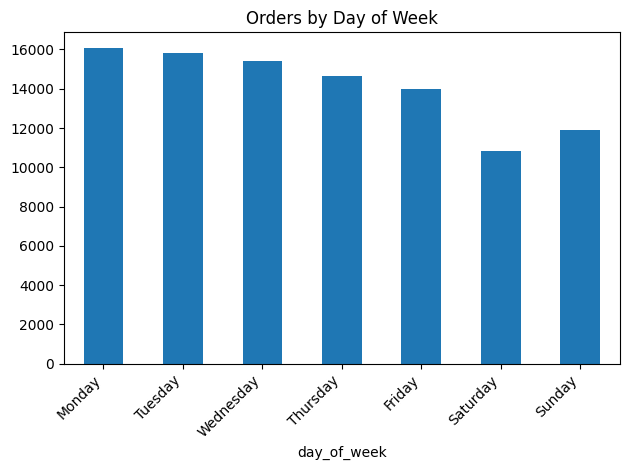

In [7]:
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
orders_by_day = df.groupby('day_of_week')['order_id'].nunique().reindex(day_order)

orders_by_day.plot(kind='bar')
plt.title("Orders by Day of Week")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Insight 2 — Customer Behavior
Order volume is highest on Monday and Tuesday, and lowest on Saturday, indicating that customer purchasing activity is concentrated during weekdays rather than weekends.

In [8]:
orders['order_delivered_customer_date'] = pd.to_datetime(orders['order_delivered_customer_date'])
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])

orders['delivery_days'] = (orders['order_delivered_customer_date'] - orders['order_purchase_timestamp']).dt.days

print(orders['delivery_days'].describe())

count    96476.000000
mean        12.094086
std          9.551746
min          0.000000
25%          6.000000
50%         10.000000
75%         15.000000
max        209.000000
Name: delivery_days, dtype: float64


## Insight 3 — Delivery Performance
Average delivery time is ~12 days, with a median of 10 days. However, the wide range (up to 209 days) indicates significant outliers, suggesting inconsistencies in logistics performance.

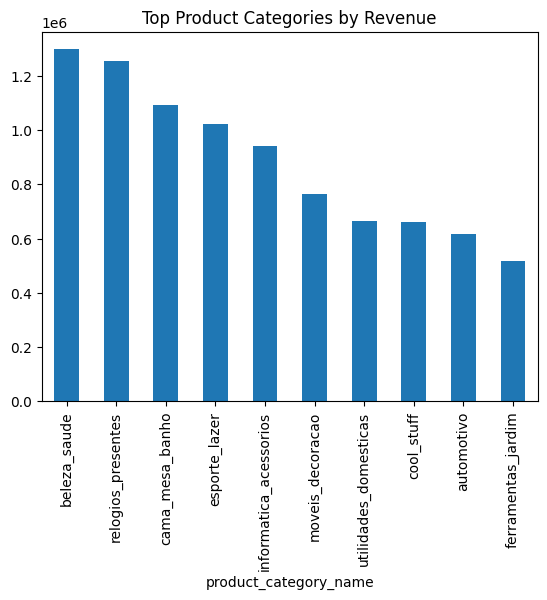

In [9]:
top_categories = df.groupby('product_category_name')['price'].sum().sort_values(ascending=False).head(10)

top_categories.plot(kind='bar')
plt.title("Top Product Categories by Revenue")
plt.show()

## Insight 4 — Product Categories
Categories like beleza_saude, relogios_presentes, and cama_mesa_banho contribute the highest revenue, indicating strong demand in personal care and home-related products.